<p style="text-align:center">
    <a href="https://skills.network" target="_blank">
    <img src="https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/assets/logos/SN_web_lightmode.png" width="200" alt="Skills Network Logo">
    </a>
</p>


# **Logistic Regression**


Logistic regression is a popular and effective model for classification tasks. Learning how it works is important because it introduces core ideas used throughout machine learning, including probability-based prediction, decision boundaries, and model evaluation. These concepts also help build a foundation for understanding more advanced models, including neural networks.
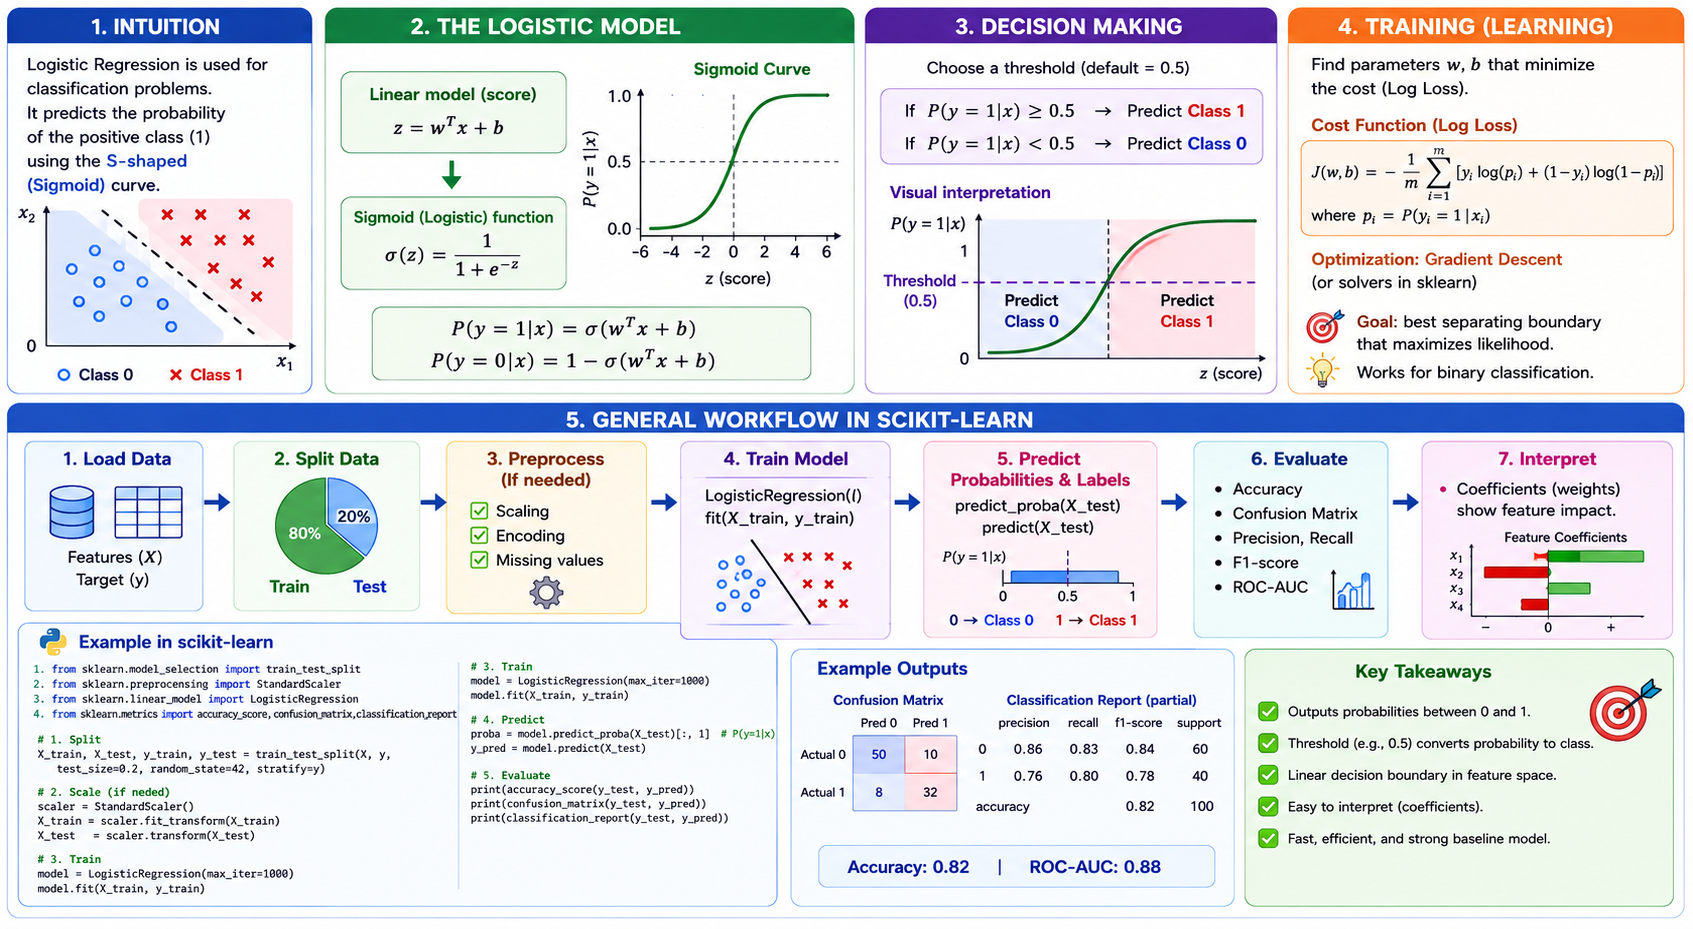

## **Introduction**

Logistic regression predicts probabilities. For binary classification, it first calculates a linear score and then converts that score into a probability using the **sigmoid** function:

$$
\begin{aligned}
z^{(i)} &= w^Tx^{(i)} + b \\
\hat{y}^{(i)} &= P(y=1|x^{(i)}) = \frac{1}{1 + e^{-z^{(i)}}}
\end{aligned}
$$

Because logistic regression predicts probabilities, it uses **log loss (also called cross entropy loss)** as its cost function. Log loss measures how far the predicted probabilities are from the true class labels during training.

For binary logistic regression, the log loss is:

$$
J(w, b) = -\frac{1}{m}\sum_{i=1}^{m}\left[y^{(i)}\log(\hat{y}^{(i)}) + (1-y^{(i)})\log(1-\hat{y}^{(i)})\right]
$$

where $\hat{y}^{(i)}$ is the predicted probability that sample $i$ belongs to class 1.

- If the true class is 1, the model is penalized when it predicts a low probability for class 1.
- If the true class is 0, the model is penalized when it predicts a high probability for class 1.

During training, logistic regression finds coefficients that minimize log loss. A smaller log loss means the model's predicted probabilities are closer to the correct labels.

**Regularization** can be added to log loss to prevent the model coefficients from becoming too large. This helps reduce overfitting.

For example, with L2 regularization, the cost becomes:

$$
J_{regularized}(w, b) = \text{log loss} + \lambda \sum_{j=1}^{n}w_j^2
$$

So the model tries to minimize both prediction error and coefficient size at the same time.


## **Objectives**


We will use a real-world dataset that contains detailed nutrition information about food items for people with diabetes. The objective is to classify whether a diabetic patient should choose *More Often*, *Less Often*, or *In Moderation* for a specific food item based on the nutrition information in the dataset.

*   Preprocess and generate training and testing datasets
*   Train and fine-tune logistic regression models
*   Interpret trained logistic regression models
*   Evaluate trained logistic regression models


***


## **Workflow**
### **Prepare and setup lab environment**


In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import OneHotEncoder, LabelEncoder, MinMaxScaler, label_binarize
from sklearn.model_selection import train_test_split, learning_curve
from sklearn.linear_model import LogisticRegression
from sklearn import metrics
from sklearn.metrics import (
    classification_report,
    accuracy_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    precision_recall_fscore_support,
    precision_score,
    recall_score,
    roc_curve,
    auc,
)

import matplotlib.pyplot as plt
import seaborn as sns
%matplotlib inline

In [6]:
# also set a random state
rs = 123

### **Exploratory Data Analysis(EDA) and Feature Engineering**
Before we get to the model implementation, it is essential to examine the dataset and carefully select the features that will serve as inputs for the model..


#### **Load and explore the dataset**


First, let's load the dataset as a `Pandas` dataframe and conduct some basic EDA tasks on it.


In [7]:
# Load the dataset
dataset_url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBM-ML241EN-SkillsNetwork/labs/datasets/food_items.csv"
food_df = pd.read_csv(dataset_url)

And, let's quickly check its column types.


In [8]:
food_df.dtypes

Calories               float64
Total Fat                int64
Saturated Fat          float64
Monounsaturated Fat    float64
Polyunsaturated Fat    float64
Trans Fat              float64
Cholesterol              int64
Sodium                 float64
Total Carbohydrate     float64
Dietary Fiber          float64
Sugars                 float64
Sugar Alcohol            int64
Protein                float64
Vitamin A                int64
Vitamin C                int64
Calcium                  int64
Iron                     int64
class                   object
dtype: object

Print the first ten food items:


In [ ]:
food_df.head(10)

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron,class
0,149.0,0,0.0,0.0,0.0,0.0,0,9.0,9.8,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
1,123.0,0,0.0,0.0,0.0,0.0,0,5.0,6.6,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
2,150.0,0,0.0,0.0,0.0,0.0,0,4.0,11.4,0.0,0.0,0,1.3,0,0,0,0,'In Moderation'
3,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
4,143.0,0,0.0,0.0,0.0,0.0,0,7.0,13.1,0.0,0.0,0,1.0,0,0,0,0,'In Moderation'
5,110.0,0,0.0,0.0,0.0,0.0,0,6.0,7.0,0.0,0.0,0,0.8,0,0,0,0,'In Moderation'
6,142.0,0,0.0,0.0,0.0,0.0,0,12.0,10.6,0.0,0.0,0,1.2,0,0,0,0,'In Moderation'
7,102.0,0,0.0,0.0,0.0,0.0,0,13.0,5.0,0.0,0.0,0,0.7,0,0,0,0,'In Moderation'
8,145.0,0,0.0,0.0,0.0,0.0,0,17.0,11.0,0.0,0.0,0,1.2,0,0,0,0,'In Moderation'
9,171.0,0,0.0,0.0,0.0,0.0,0,8.0,13.7,0.0,0.0,0,2.5,0,0,0,0,'In Moderation'


Get the row entries with col 0 to -1 (16).


In [ ]:
feature_cols = list(food_df.iloc[:, :-1].columns)
feature_cols

['Calories',
 'Total Fat',
 'Saturated Fat',
 'Monounsaturated Fat',
 'Polyunsaturated Fat',
 'Trans Fat',
 'Cholesterol',
 'Sodium',
 'Total Carbohydrate',
 'Dietary Fiber',
 'Sugars',
 'Sugar Alcohol',
 'Protein',
 'Vitamin A',
 'Vitamin C',
 'Calcium',
 'Iron']

Obtain descriptive statistics:


In [11]:
food_df.iloc[:, :-1].describe()

,Calories,Total Fat,Saturated Fat,Monounsaturated Fat,Polyunsaturated Fat,Trans Fat,Cholesterol,Sodium,Total Carbohydrate,Dietary Fiber,Sugars,Sugar Alcohol,Protein,Vitamin A,Vitamin C,Calcium,Iron
count,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000,13260.000000
mean,133.861086,4.475264,1.450617,0.338069,0.254660,0.047459,8.857692,241.867142,18.232020,1.602971,6.645234,0.117949,4.661333,6.287632,6.741855,5.175264,5.235671
std,94.227650,5.386340,2.410318,1.345852,2.230586,0.321402,20.976530,272.284363,14.786316,3.363879,8.328465,1.121529,5.611143,18.374191,23.785100,8.779637,9.119459
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,70.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,40.000000,5.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
50%,120.000000,3.000000,0.500000,0.000000,0.000000,0.000000,0.000000,135.000000,17.000000,1.000000,3.000000,0.000000,3.000000,0.000000,0.000000,2.000000,2.000000
75%,180.000000,7.000000,2.000000,0.000000,0.000000,0.000000,10.000000,370.000000,27.000000,2.000000,11.000000,0.000000,7.000000,6.000000,2.000000,6.000000,8.000000
max,2210.000000,43.000000,22.000000,40.000000,235.000000,11.000000,450.000000,2431.000000,270.000000,305.000000,115.000000,31.000000,70.000000,622.000000,1000.000000,110.000000,170.000000


As we can see from the above output, this dataset contains 17 nutrient categories about each food item. These categories include Calories, Total Fat, Protein, Sugar, etc., and are listed as numeric variables. As such, we only need to scale them for training our logistic regression model so that we can compare our feature coefficients directly. This will be done under the feature engineering section.


#### **Multiclass Variable**
Next, let's check the target variable in the `class` column to see the label values and their distribution.


In [12]:
# # Get the row entries with the last col 'class'
food_df.iloc[:, -1:].value_counts(normalize=True)

class          
'In Moderation'    0.501433
'Less Often'       0.423906
'More Often'       0.074661
Name: proportion, dtype: float64

<Axes: xlabel='class'>

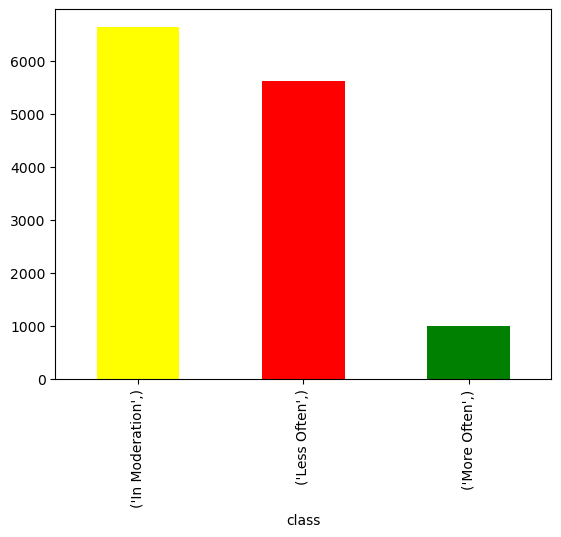

In [ ]:
food_df.iloc[:, -1:].value_counts().plot.bar(color=["yellow", "red", "green"])

As we can see from the bar chart above, this dataset has three classes: `In Moderation`, `Less Often`, and `More Often`. The three labels are imbalanced. For diabetic patients, most food items are in the In Moderation and Less Often categories. This makes diabetes diet management very hard, so we could build a machine learning model to help patients choose their food.


Because the target variable has three labels, this is a multiclass classification problem. Logistic regression can handle multiclass problems in two common ways: **multinomial logistic regression** and **one-vs-rest logistic regression**.

In this lab, we use **multinomial logistic regression**. It calculates one score for each class, then uses softmax to convert those scores into probabilities:

$$
\begin{aligned}
P(\text{class } k) &= \frac{\exp(score_k)}{\sum_j \exp(score_j)}
\end{aligned}
$$

For our three classes, the model produces probabilities for `In Moderation`, `Less Often`, and `More Often`. The predicted class is the one with the highest probability.


This is different from the **one-vs-rest** approach. In one-vs-rest, we train one separate binary logistic regression classifier for each class. Each classifier asks: "Is this sample in this class, or not?"

For one class, the probability is calculated with the sigmoid function:

$$
\begin{aligned}
P(\text{class } k \text{ vs rest}) &= \frac{1}{1 + e^{-score_k}}
\end{aligned}
$$

For example, one classifier would learn `More Often` vs `Not More Often`, where `Not More Often` includes both `In Moderation` and `Less Often`.


#### **Feature Engineering**


Now you should have some basic understanding about the food dataset. Next, let's process the raw dataset and construct input data `X` and label/output `y` for logistic regression model training.


In [14]:
X_raw = food_df.iloc[:, :-1]
y_raw = food_df.iloc[:, -1:]

Fortunately, all feature columns are numeric so we just need to scale them. Here we use the `MinMaxScaler` provided by `sklearn` for scaling.


In [15]:
# Create a MinMaxScaler object
scaler = MinMaxScaler()

In [16]:
# Scaling the raw input features
X = scaler.fit_transform(X_raw)

Let's check the scaled feature value range:


In [17]:
print(f"The range of feature inputs are within {X.min()} to {X.max()}")

The range of feature inputs are within 0.0 to 1.0


For the target variable `y`, let's use the `LabelEncoder` provided by `sklearn` to encode its three class values.


In [18]:
# Create a LabelEncoder object
label_encoder = LabelEncoder()

In [19]:
# Encode the target variable
y = label_encoder.fit_transform(y_raw.values.ravel())
# Note that ravel() function flattens the vector.

The encoded target variable will only contain values `0=In Moderation`, `1=Less Often`, `2=More Often`.


In [20]:
np.unique(y, return_counts=True)

(array([0, 1, 2]), array([6649, 5621,  990]))

### **Train logistic regression models**

#### **Stratify Train Test Split**

First, let's split the data into training and testing sets. The training set is used to train the model. The testing set is kept separate and used to evaluate the model after training.

Because this is a classification problem, we use `stratify=y`. This keeps the class proportions similar in the training and testing sets. For example, if one class is less common in the full dataset, `stratify=y` helps make sure that class is still represented in both splits.

If needed, the training set can also be split again into a smaller training set and a validation set for tuning model parameters.


In [ ]:
# First, let's split the training and testing dataset
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=rs
)

Let's look at the shapes of the split datasets:


In [ ]:
print(
    f"Training dataset shape, X_train: {X_train.shape}, y_train: {y_train.shape}"
)

Training dataset shape, X_train: (10608, 17), y_train: (10608,)


In [23]:
print(f"Testing dataset shape, X_test: {X_test.shape}, y_test: {y_test.shape}")

Testing dataset shape, X_test: (2652, 17), y_test: (2652,)


#### **Multiclass Classification**

Logistic regression is often introduced as a binary classification model. In binary classification, the model calculates one score and uses the sigmoid function to convert that score into the probability of class 1:

$$
\begin{aligned}
z &= b + w_1x_1 + w_2x_2 + \cdots + w_nx_n \\
P(\text{class 1}) &= \frac{1}{1 + e^{-z}}
\end{aligned}
$$

For multiclass classification, logistic regression can be extended in two common ways: **one-vs-rest** or **multinomial logistic regression**.

- In one-vs-rest, the model trains one binary classifier for each class.
- In multinomial logistic regression, one model calculates a score for each class and compares the classes together using softmax.

This lab uses three encoded classes: `0=In Moderation`, `1=Less Often`, and `2=More Often`. For multinomial logistic regression, the model calculates one score for each class:

$$
\begin{aligned}
score_0 &= \text{class 0 intercept} + \text{class 0 coefficients} \times \text{input features} \\
score_1 &= \text{class 1 intercept} + \text{class 1 coefficients} \times \text{input features} \\
score_2 &= \text{class 2 intercept} + \text{class 2 coefficients} \times \text{input features}
\end{aligned}
$$

The model is trained on all classes at the same time, but it learns a separate coefficient row for each class. Softmax then converts the three class scores into probabilities that add up to 1:

$$
\begin{aligned}
P(\text{class 0}) &= \frac{\exp(score_0)}{\exp(score_0) + \exp(score_1) + \exp(score_2)} \\
P(\text{class 1}) &= \frac{\exp(score_1)}{\exp(score_0) + \exp(score_1) + \exp(score_2)} \\
P(\text{class 2}) &= \frac{\exp(score_2)}{\exp(score_0) + \exp(score_1) + \exp(score_2)}
\end{aligned}
$$

The predicted class is the class with the highest probability. 


#### **Logistic Regression Solvers**
We first define a `sklearn.linear_model.LogisticRegression` model with the following arguments, you can check the comment for each argument for what it means.

Logistic Regression Solvers: `lbfgs` vs `saga`

A **solver** is the optimization method logistic regression uses to find the best model coefficients.

- `solver='lbfgs'` uses the L-BFGS optimization algorithm. It is gradient-based and approximates the curvature of the loss function to choose efficient update directions. It works well for standard logistic regression with `l2` regularization (penalty), but does not support `l1` or `elasticnet`.

- `solver='saga'` uses the SAGA optimization algorithm. It is also gradient-based, but closer to stochastic gradient descent. It updates the model using small parts of the data and past gradient information to improve convergence. It supports `l1`, `l2`, and `elasticnet`, so it is used for elastic-net logistic regression.

In short:

- `lbfgs`: good default for `l2` logistic regression.
- `saga`: needed for `l1` or `elasticnet` logistic regression.

In [ ]:
# L2 penalty to shrink coefficients without removing any features from the model
penalty = "l2"
# Our classification problem is multinomial
multi_class = "multinomial"
# Use lbfgs for L2 penalty and multinomial classes
solver = "lbfgs"
# Max iteration = 1000
max_iter = 1000

In [ ]:
# Define a logistic regression model with above arguments
l2_model = LogisticRegression(
    random_state=rs,
    penalty=penalty,
    multi_class=multi_class,
    solver=solver,
    max_iter=max_iter,
)

Let's train the model with training input data `X_train` and labels `y_train`:


In [26]:
l2_model.fit(X_train, y_train)

/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'lbfgs'
,max_iter,1000
,multi_class,'multinomial'


In [27]:
l2_preds = l2_model.predict(X_test)

Because we may need to evaluate the model multiple times with different model hyper parameters, here we define an utility method to take the ground truths `y_test` and the predictions `preds`, and return a Python `dict` with `accuracy`, `recall`, `precision`, and `f1score`.


In [ ]:
def evaluate_metrics(yt, yp):
    results_pos = {}
    results_pos["accuracy"] = accuracy_score(yt, yp)
    precision, recall, f_beta, _ = precision_recall_fscore_support(yt, yp)
    results_pos["recall"] = recall
    results_pos["precision"] = precision
    results_pos["f1score"] = f_beta
    return results_pos

In [29]:
evaluate_metrics(y_test, l2_preds)

{'accuracy': 0.7748868778280543,
 'recall': array([0.87368421, 0.73220641, 0.35353535]),
 'precision': array([0.73035827, 0.83553299, 0.92105263]),
 'f1score': array([0.79561794, 0.78046468, 0.51094891])}

As we can see from  the above evaluation results, the logistic regression model has relatively good performance on this multinomial classification task. The overall accuracy is around `0.77` and the f1score is around `0.8`. Note that for `recall`, `precision`, and `f1score`, we output the values for each class to see how the model performs on an individual class. And, we can see from the results, the recall for `class=2` (More often) is not very good. This is actually a common problem called imbalanced classification challenge. We will introduce solution to this problem later in this course.


Next, let's try defining another logistic regression model with L1 penalty this time, to see if our classification performance would be improved.


In [ ]:
# L1 penalty to shrink coefficients without removing any features from the model
penalty = "l1"
# Our classification problem is multinomial
multi_class = "multinomial"
# Use saga for L1 penalty and multinomial classes
solver = "saga"
# Max iteration = 1000
max_iter = 1000

Then we define another logistic regression model with above arguments using L1 penalty and related solver.


In [ ]:
# Define a logistic regression model with above arguments
l1_model = LogisticRegression(
    random_state=rs,
    penalty=penalty,
    multi_class=multi_class,
    solver=solver,
    max_iter=1000,
)

We can start to train the new `l1_model` with the new taining dataset.


In [32]:
l1_model.fit(X_train, y_train)

/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


,penalty,'l1'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,123
,solver,'saga'
,max_iter,1000
,multi_class,'multinomial'


And, make predictions using the input in the test dataset.


In [33]:
l1_preds = l1_model.predict(X_test)

We can also check the class probability distribution using the `predict_proba` function. For example, we want to see the probabilities of belonging to each class for the first instance in the test dataset:


In [34]:
class_probabilities = l1_model.predict_proba(X_test[:1, :])[0]
class_probabilities

array([3.55065558e-02, 9.64491964e-01, 1.47991419e-06])

We can see that  Class 1 has the largest probability 0.96. As such, the model prediction for this instance will be class `1` and this is the same as the `predict` method.


In [35]:
l1_model.predict(X_test[:1, :])[0]

1

Given the true labels (`y_test`) and predictions, we can evaluate the model performance by calling the utility `evaluate_metrics`  method.


In [36]:
evaluate_metrics(y_test, l1_preds)

{'accuracy': 0.8092006033182504,
 'recall': array([0.85488722, 0.74377224, 0.87373737]),
 'precision': array([0.78848821, 0.83516484, 0.8277512 ]),
 'f1score': array([0.82034632, 0.78682353, 0.85012285])}

Now, we can see this logistic regression with l1 penalty has much better performance than l2. One possible reason is that l1 penalty may remove some correlated feature variables by shrinking their coefficents to zero. As such, the model is much simplified to avoid overfitting on the training data and better aligned with the logistic regression assumption that all features should be independent.


#### **Multiclass Evaluation Metrics**
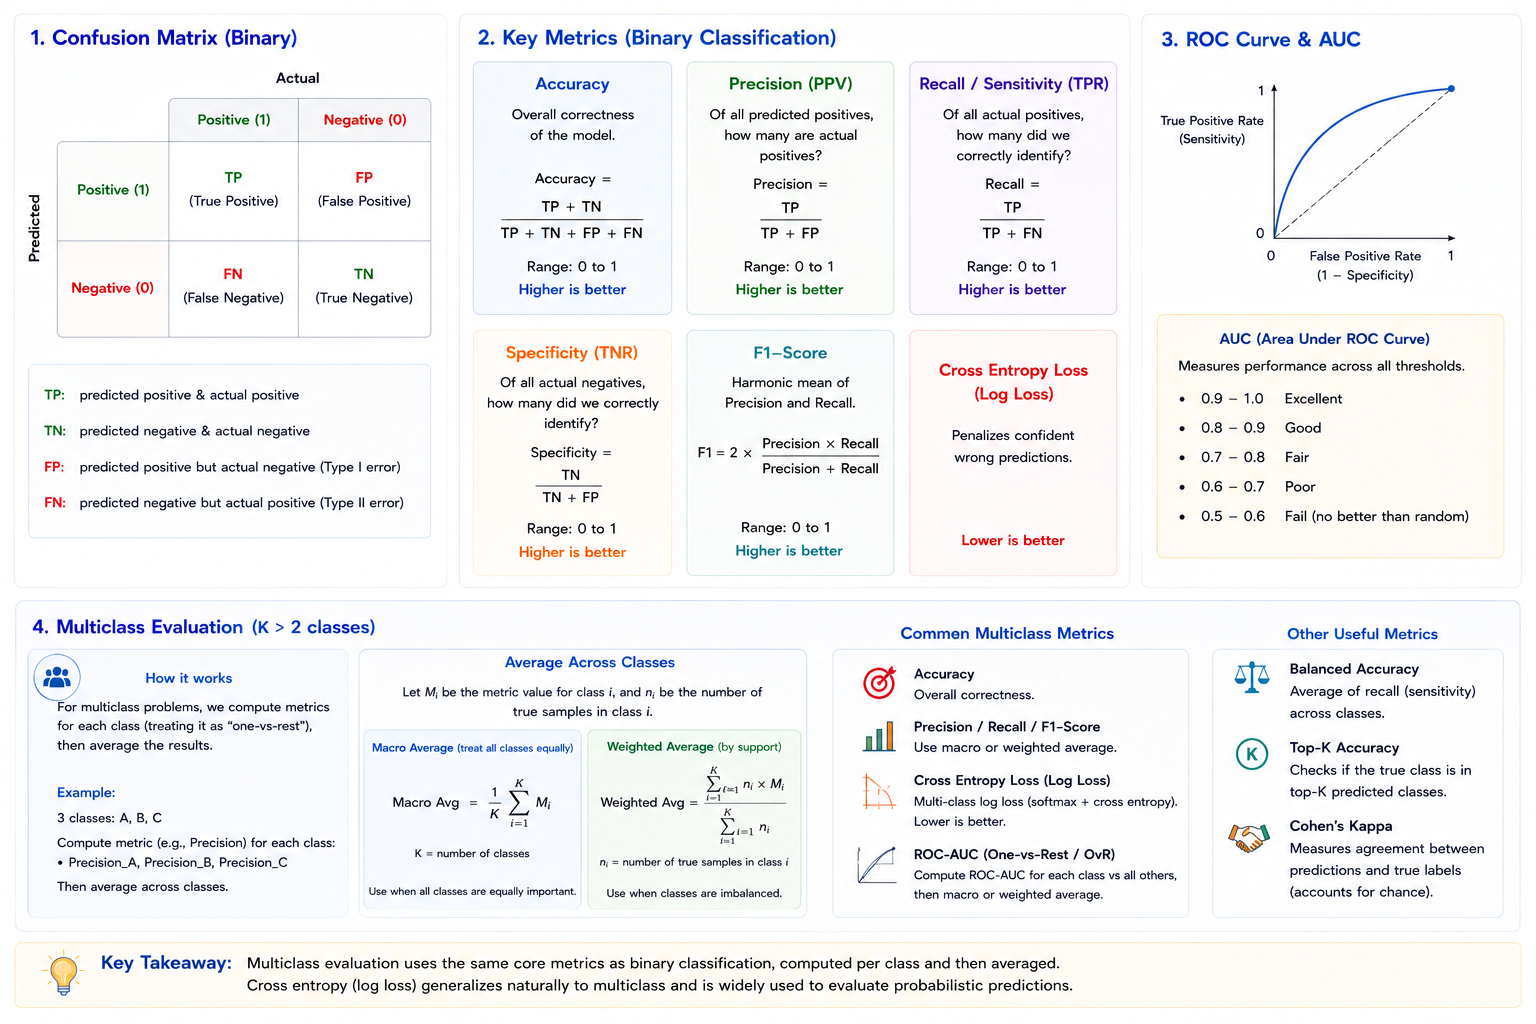
For multiclass classification, precision, recall, and F1-score can be calculated for each class using a **one-vs-rest** view. This means one class is treated as the positive class, and all other classes are grouped together as the negative class.

For example, when evaluating class 2:

$$
\begin{aligned}
\text{positive class} &= \text{class 2} \\
\text{negative class} &= \text{class 0 and class 1}
\end{aligned}
$$

Precision, recall, and F1-score are then calculated for class 2 as if it were a binary classification problem:

$$
\begin{aligned}
\text{precision} &= \frac{\text{correct class 2 predictions}}{\text{all predicted class 2}} \\
\text{recall} &= \frac{\text{correct class 2 predictions}}{\text{all actual class 2}} \\
\text{F1-score} &= \text{balance between precision and recall}
\end{aligned}
$$

Accuracy is different because it is calculated across all classes at once:

$$
\text{accuracy} = \frac{\text{total correct predictions}}{\text{total predictions}}
$$



We can also plot the confusion matrix based on the true labels and predictions using the `confusion_matrix` method provided by `sklearn`,


In [ ]:
cf = confusion_matrix(y_test, l1_preds, normalize="true")

and easily visualize it using a heatmap method provided by `seaborn`.


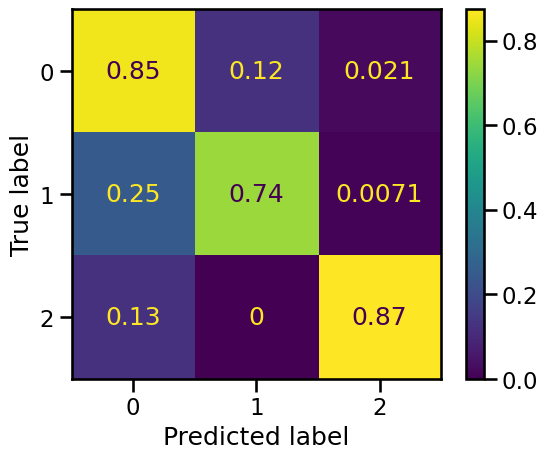

In [ ]:
sns.set_context("talk")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cf, display_labels=l1_model.classes_
)
disp.plot()
plt.show()

#### **Multiclass ROC/AUC**

A multinomial model predicts the class with the highest probability, so normal prediction does not require a threshold. ROC/AUC is different because it is a binary evaluation method. To use ROC/AUC with a multinomial model, we evaluate each class with a **one-vs-rest** setup.

For example, to draw the ROC curve for class 2, we use only:

$$
P(\text{class 2})
$$

Then we evaluate `class 2` vs `not class 2`. The ROC curve tests many thresholds for $P(\text{class 2})$ and calculates:

$$
\begin{aligned}
\text{True Positive Rate} &= \frac{\text{correctly predicted class 2}}{\text{all actual class 2}} \\
\text{False Positive Rate} &= \frac{\text{incorrectly predicted class 2}}{\text{all actual not class 2}}
\end{aligned}
$$

The ROC curve plots:

$$
\begin{aligned}
x\text{-axis} &= \text{False Positive Rate} \\
y\text{-axis} &= \text{True Positive Rate}
\end{aligned}
$$

AUC is the area under the ROC curve. A larger AUC means better separation between that class and the other classes:

$$
\begin{aligned}
\text{AUC close to 1} &= \text{strong separation} \\
\text{AUC close to 0.5} &= \text{close to random guessing}
\end{aligned}
$$

We repeat this one-vs-rest evaluation for every class:

$$
\begin{aligned}
\text{class 0} &\text{ vs not class 0} \\
\text{class 1} &\text{ vs not class 1} \\
\text{class 2} &\text{ vs not class 2}
\end{aligned}
$$

So the model is trained as multinomial, but ROC/AUC is evaluated one class at a time. This gives one ROC curve and one AUC score for each class.


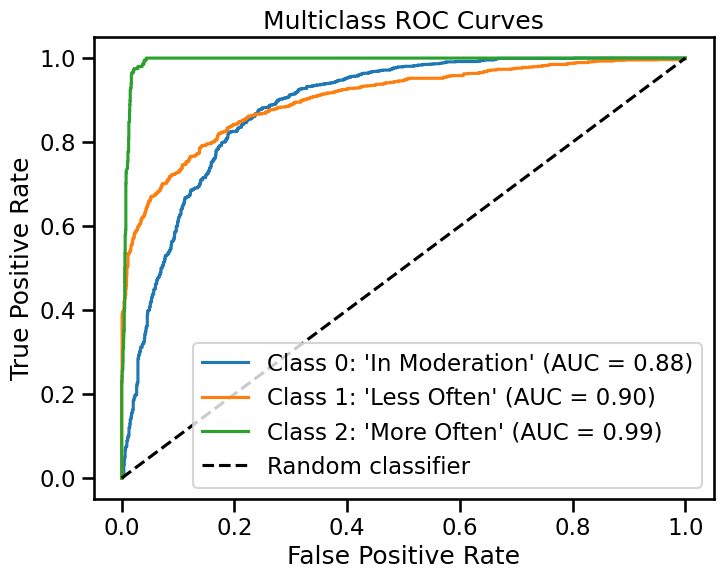

In [ ]:
# Get predicted probabilities for each class
y_score = l1_model.predict_proba(X_test)

# Convert y_test into one-vs-rest binary format
y_test_bin = label_binarize(y_test, classes=l1_model.classes_)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for class_index, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, class_index], y_score[:, class_index]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {class_index}: {class_name} (AUC = {roc_auc:.2f})",
    )

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend()
plt.show()

#### **Interpret logistic regression models**


One way to interpret logistic regression models is by analyzing feature coefficients. Although it may not be as effective as the regular linear regression models because the logistic regression model has a sigmoid function, we can still get a sense for the importance or impact of each feature.  


We can check the coefficients for logistic regression model using its `coef_` attribute:


In [40]:
l1_model.coef_

array([[ 1.02260612e+01,  0.00000000e+00,  0.00000000e+00,
         5.28211590e+00,  0.00000000e+00, -3.70560617e+00,
         0.00000000e+00,  9.11923717e-01,  0.00000000e+00,
         2.26627496e+01,  0.00000000e+00,  0.00000000e+00,
         4.30564271e+00,  1.36942545e-01,  0.00000000e+00,
         1.83340368e+00, -2.06761520e-02],
       [ 0.00000000e+00,  4.20223530e+00,  2.46648466e+01,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         4.94277520e+00,  0.00000000e+00,  1.32251480e+00,
        -6.79834695e+00,  1.51669845e+01,  3.46648083e+00,
         0.00000000e+00, -1.71144958e+00,  0.00000000e+00,
        -1.47866235e-01,  0.00000000e+00],
       [-1.11431018e+02, -2.91410454e+01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00, -1.59642876e+00, -4.13437893e+01,
         0.00000000e+00, -9.27079323e-01,  0.00000000e+00,
         0.00000000e+00,  0.00000000e+00,  0.00000000e+00,
         0.00000000e+00,  0.0

The `coef_` is a coefficients list with three elements, one element is the actual coefficent for class 0, 1, 2. To better analyze the coefficients, let's use three utility methods to sort and visualize them.


In [ ]:
# Extract and sort feature coefficients
def get_feature_coefs(regression_model, label_index, columns):
    coef_dict = {}
    for coef, feat in zip(regression_model.coef_[label_index, :], columns):
        if abs(coef) >= 0.01:
            coef_dict[feat] = coef
    # Sort coefficients
    coef_dict = {
        k: v for k, v in sorted(coef_dict.items(), key=lambda item: item[1])
    }
    return coef_dict


# Generate bar colors based on if value is negative or positive
def get_bar_colors(values):
    color_vals = []
    for val in values:
        if val <= 0:
            color_vals.append("r")
        else:
            color_vals.append("g")
    return color_vals


# Visualize coefficients
def visualize_coefs(coef_dict):
    features = list(coef_dict.keys())
    values = list(coef_dict.values())
    y_pos = np.arange(len(features))
    color_vals = get_bar_colors(values)
    plt.rcdefaults()
    fig, ax = plt.subplots()
    ax.barh(y_pos, values, align="center", color=color_vals)
    ax.set_yticks(y_pos)
    ax.set_yticklabels(features)
    # labels read top-to-bottom
    ax.invert_yaxis()
    ax.set_xlabel("Feature Coefficients")
    ax.set_title("")
    plt.show()

Then, let's visualize the sorted coefficient for class 1, the `Less Often` class: 


In [42]:
# Get the coefficents for Class 1, Less Often
coef_dict = get_feature_coefs(l1_model, 1, feature_cols)

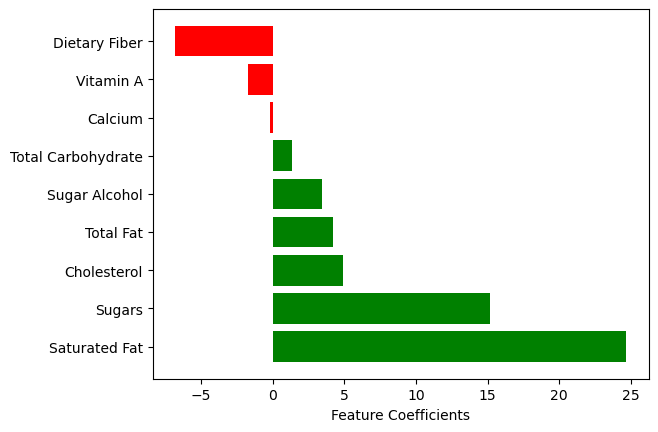

In [43]:
visualize_coefs(coef_dict)

As we can see, unhealthy nutrients such as Saturated Fat, Sugars, Cholesterol, Total Fat, etc., have high positive coefficients. Food items containing unhealthy nutrients will have higher coeficients and will be more likely to be categorized in the 'Less Often' class.


Next, let's see the coefficents for Class 2, `More Often`:


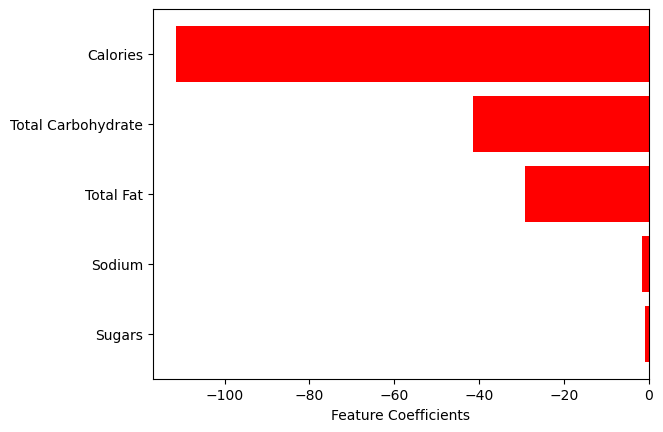

In [44]:
# Coefficients for Class 2
coef_dict = get_feature_coefs(l1_model, 2, feature_cols)
visualize_coefs(coef_dict)

Conversely, if a food item has a high amount of calories, total carbohydrates, and total fat, then it is unlikely to be categorized in the 'More Often' class.


### **Coding Exercise**


Now it is your turn to work through the full process of defining, training, evaluating, and interpreting an elastic-net logistic regression model.


#### **Define a logistic regression with elastic-net penalty**

In [ ]:
# Elastic-net penalty to shrink coefficients and allow some feature selection
penalty = "elasticnet"
multi_class = "multinomial"
solver = "saga"
max_iter = 1000
l1_ratio = 0.1

# Define an elastic-net logistic regression model
en_model = LogisticRegression(
    random_state=rs,
    penalty=penalty,
    multi_class=multi_class,
    solver=solver,
    max_iter=max_iter,
    l1_ratio=l1_ratio,
)

The elastic-net model is set up for multiclass logistic regression. The `saga` solver is appropriate because it supports elastic-net regularization, and `l1_ratio=0.1` makes the model mostly L2-regularized with a small L1 feature-selection effect.


#### **Train the model with training data**


In [ ]:
en_model.fit(X_train, y_train)
en_preds = en_model.predict(X_test)

/home/wusu/anaconda3/envs/Python_3_10/lib/python3.10/site-packages/sklearn/linear_model/_logistic.py:1272: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.8. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


The model is trained on the training set and then used to predict the test set labels. This creates the predictions needed for the evaluation steps below.


#### **Evaluate the model using accuracy, precision, recall, and F1 score**


In [ ]:
en_metrics = evaluate_metrics(y_test, en_preds)
en_metrics

{'accuracy': 0.7782805429864253,
 'recall': array([0.87218045, 0.73220641, 0.40909091]),
 'precision': array([0.73510773, 0.83553299, 0.91011236]),
 'f1score': array([0.79779917, 0.78046468, 0.56445993])}

In [ ]:
print(classification_report(y_test, en_preds))

              precision    recall  f1-score   support

           0       0.74      0.87      0.80      1330
           1       0.84      0.73      0.78      1124
           2       0.91      0.41      0.56       198

    accuracy                           0.78      2652
   macro avg       0.83      0.67      0.71      2652
weighted avg       0.79      0.78      0.77      2652



**Findings:**

The elastic-net model correctly predicts about 78% of the test examples. It works better for class `0` and class `1` than for class `2` (`More Often`). For class `2`, high precision means that when the model predicts `More Often`, it is usually correct. Lower recall means the model misses many food items that truly belong in the `More Often` class.


#### **Confusion matrix**


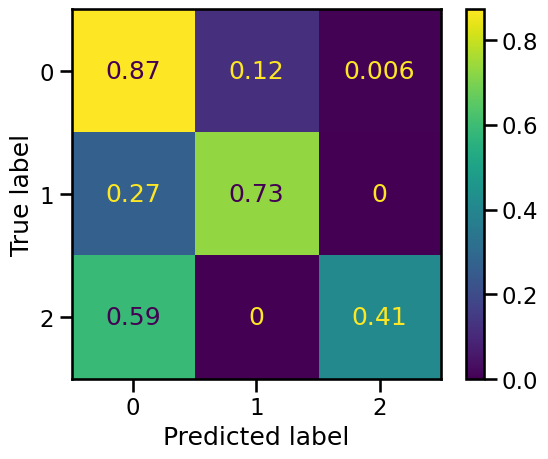

In [ ]:
cf = confusion_matrix(y_test, en_preds, normalize="true")

sns.set_context("talk")
disp = ConfusionMatrixDisplay(
    confusion_matrix=cf, display_labels=en_model.classes_
)
disp.plot()
plt.show()

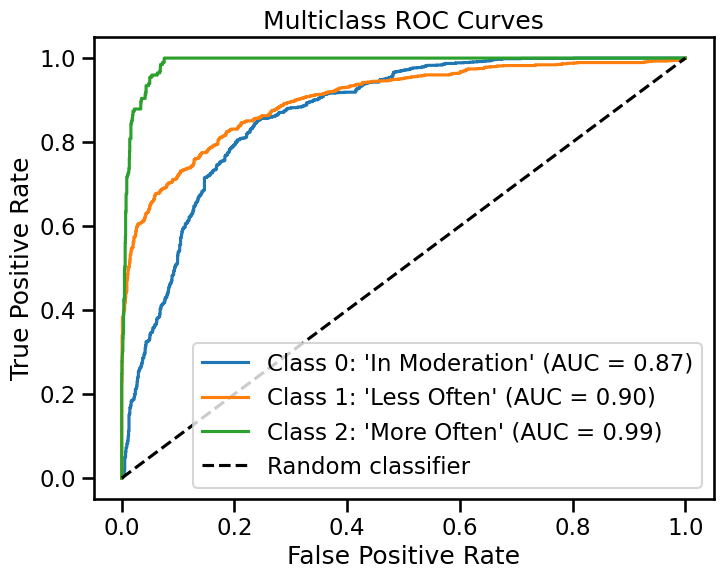

In [ ]:
# Get predicted probabilities for each class
y_score = en_model.predict_proba(X_test)

# Convert y_test into one-vs-rest binary format
y_test_bin = label_binarize(y_test, classes=en_model.classes_)

# Plot ROC curve for each class
plt.figure(figsize=(8, 6))

for class_index, class_name in enumerate(label_encoder.classes_):
    fpr, tpr, thresholds = roc_curve(
        y_test_bin[:, class_index], y_score[:, class_index]
    )
    roc_auc = auc(fpr, tpr)

    plt.plot(
        fpr,
        tpr,
        label=f"Class {class_index}: {class_name} (AUC = {roc_auc:.2f})",
    )

# Plot random classifier baseline
plt.plot([0, 1], [0, 1], "k--", label="Random classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Multiclass ROC Curves")
plt.legend()
plt.show()

**Findings:** The confusion matrix and ROC curves show that the model separates the classes better than random guessing. However, class `2` remains the hardest class to identify, which matches the lower recall seen in the metrics.


#### **Interpret the model by analyzing its coefficients**


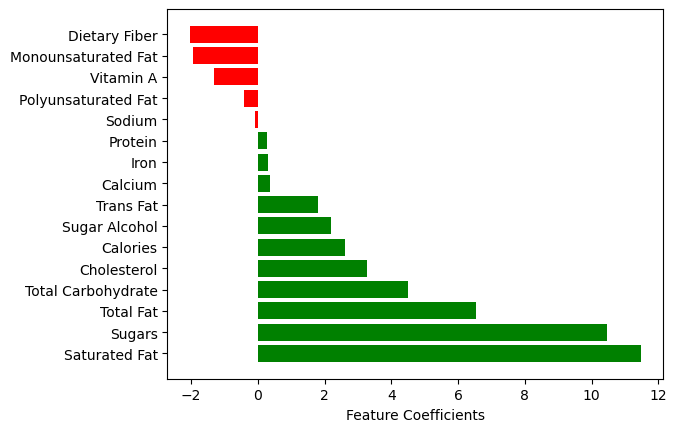

In [ ]:
# Get and visualize the coefficients for Class 1, Less Often
coef_dict = get_feature_coefs(en_model, 1, feature_cols)
visualize_coefs(coef_dict)

Class 0: 'In Moderation'


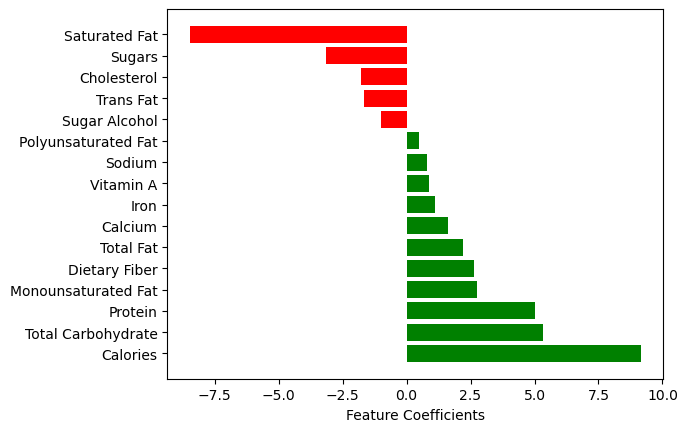

Class 1: 'Less Often'


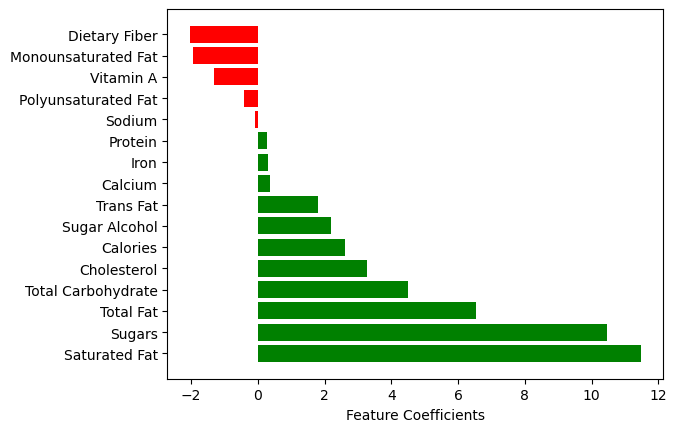

Class 2: 'More Often'


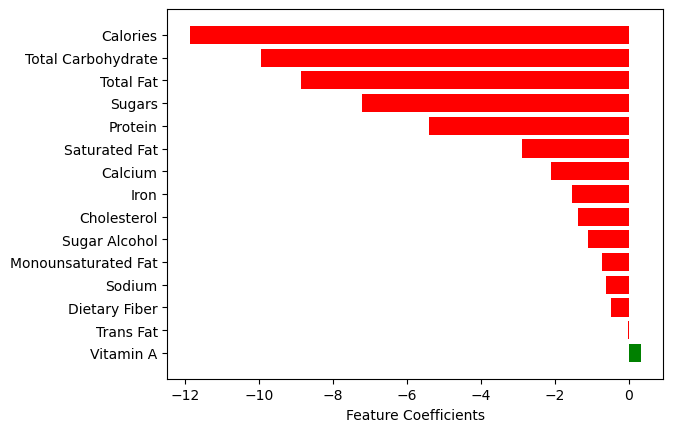

In [52]:
# Coefficients for all classes
for class_index, class_name in enumerate(label_encoder.classes_):
    print(f"Class {class_index}: {class_name}")
    coef_dict = get_feature_coefs(en_model, class_index, feature_cols)
    visualize_coefs(coef_dict)

**Findings:**

The coefficient plots show different nutrition patterns for each class.
>For class `0` (`In Moderation`), higher calories, total carbohydrates, protein, dietary fiber, and total fat increase the class score, while saturated fat and sugars decrease it. 

>For class `1` (`Less Often`), saturated fat and sugars have the strongest positive coefficients, so foods high in these nutrients are more likely to be classified as `Less Often`. 

>For class `2` (`More Often`), calories, total carbohydrates, total fat, sugars, and protein have strong negative coefficients, meaning foods with higher amounts of these nutrients are less likely to be recommended `More Often`.


## **Authors**


[Yan Luo](https://www.linkedin.com/in/yan-luo-96288783/?utm_medium=Exinfluencer&utm_source=Exinfluencer&utm_content=000026UJ&utm_term=10006555&utm_id=NA-SkillsNetwork-Channel-SkillsNetworkCoursesIBMML241ENSkillsNetwork31576874-2021-01-01)

Su Wu

Copyright © 2021 IBM Corporation. All rights reserved.
